In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split


In [30]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [31]:
# Kiểm tra thông tin chung
print("Thông tin dữ liệu:")
df.info()

print("\nKích thước dữ liệu:", df.shape)

print("\nThống kê mô tả:")
display(df.describe())

print("\nSố giá trị null mỗi cột:")
print(df.isnull().sum())

for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}: {df[col].unique()}")


Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB

Kích thước dữ liệu: (5110, 12)

Thống kê mô tả:


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000



Số giá trị null mỗi cột:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

gender: ['Male' 'Female' 'Other']

ever_married: ['Yes' 'No']

work_type: ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']

Residence_type: ['Urban' 'Rural']

smoking_status: ['formerly smoked' 'never smoked' 'smokes' 'Unknown']


In [32]:
# Module 3: Data Cleaning

# Xử lý giá trị null (nếu có)
df['bmi'] = df['bmi'].fillna(df['bmi'].median())   # thay giá trị thiếu bằng median

# Chuẩn hóa dữ liệu không hợp lệ
df['gender'] = df['gender'].replace('Other', 'Male')  # hoặc có thể drop 'Other' nếu quá ít

# Kiểm tra trùng lặp
print("Số dòng trùng lặp:", df.duplicated().sum())
df = df.drop_duplicates()

print("\nSau khi làm sạch:")
df.info()


Số dòng trùng lặp: 0

Sau khi làm sạch:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [33]:
# Chuyển kiểu dữ liệu categorical thành số
cat_cols = df.select_dtypes(include='object').columns
print("Các cột dạng categorical:", list(cat_cols))

# Áp dụng Label Encoding cho dữ liệu dạng chuỗi
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Kiểm tra lại
df.head()


Các cột dạng categorical: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,51676,0,61.0,0,0,1,3,0,202.21,28.1,2,1
2,31112,1,80.0,0,1,1,2,0,105.92,32.5,2,1
3,60182,0,49.0,0,0,1,2,1,171.23,34.4,3,1
4,1665,0,79.0,1,0,1,3,0,174.12,24.0,2,1


In [34]:
# Tách đặc trưng và nhãn
X = df.drop('stroke', axis=1)
y = df['stroke']

# Chuẩn hóa các giá trị số
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Chuyển lại về DataFrame cho tiện theo dõi
X = pd.DataFrame(X_scaled, columns=X.columns)

print("Dữ liệu sau khi chuẩn hóa:")
X.head()


Dữ liệu sau khi chuẩn hóa:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,-1.298312,1.189510,1.051434,-0.328602,4.185032,0.723884,-0.153836,0.984080,2.706375,1.005086,-0.351781
1,0.716371,-0.840682,0.786070,-0.328602,-0.238947,0.723884,0.763438,-1.016178,2.121559,-0.098981,0.581552
2,-0.255478,1.189510,1.626390,-0.328602,4.185032,0.723884,-0.153836,-1.016178,-0.005028,0.472536,0.581552
3,1.118363,-0.840682,0.255342,-0.328602,-0.238947,0.723884,-0.153836,0.984080,1.437358,0.719327,1.514885
4,-1.647136,-0.840682,1.582163,3.043196,-0.238947,0.723884,0.763438,-1.016178,1.501184,-0.631531,0.581552


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   int64  
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   int64  
 6   work_type          5110 non-null   int64  
 7   Residence_type     5110 non-null   int64  
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     5110 non-null   int64  
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(9)
memory usage: 479.2 KB


In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Kích thước tập huấn luyện:", X_train.shape)
print("Kích thước tập kiểm tra:", X_test.shape)


Kích thước tập huấn luyện: (4088, 11)
Kích thước tập kiểm tra: (1022, 11)


Logistic Regression Accuracy: 0.9500978473581213
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



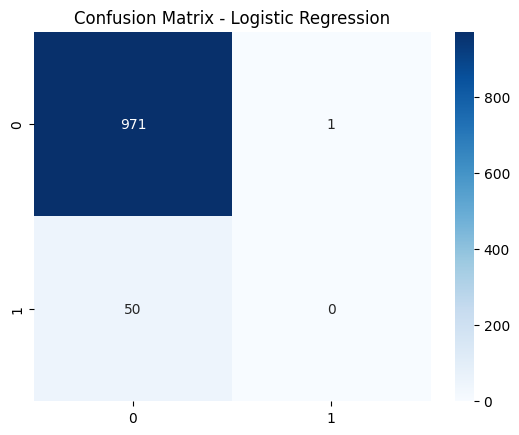

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


In [38]:
# Dự đoán nhãn cho tập test
y_test_pred = log_reg.predict(X_test)

# Dự đoán xác suất mỗi lớp (nếu cần dùng để phân tích)
y_test_prob = log_reg.predict_proba(X_test)

print("Dự đoán nhãn cho tập test:")
print(y_test_pred)

print("\nXác suất dự đoán (mỗi hàng tương ứng 1 mẫu test):")
print(y_test_prob)


Dự đoán nhãn cho tập test:
[0 0 0 ... 0 0 0]

Xác suất dự đoán (mỗi hàng tương ứng 1 mẫu test):
[[0.9477356  0.0522644 ]
 [0.98355175 0.01644825]
 [0.99397214 0.00602786]
 ...
 [0.97359936 0.02640064]
 [0.99784936 0.00215064]
 [0.97950454 0.02049546]]


In [39]:
import pandas as pd

df_compare = pd.DataFrame({
    'Thực tế (y_test)': y_test,
    'Dự đoán (y_pred)': y_test_pred
})

print("\nSo sánh thực tế và dự đoán:")
print(df_compare.head(10))  # Hiển thị 10 mẫu đầu


So sánh thực tế và dự đoán:
      Thực tế (y_test)  Dự đoán (y_pred)
3725                 0                 0
4481                 0                 0
1545                 0                 0
1820                 0                 0
1262                 0                 0
3618                 0                 0
254                  0                 0
628                  0                 0
3426                 0                 0
2687                 0                 0


In [40]:
sample = X_test.iloc[0:1]  # 1 sample

print("Dự đoán nhãn cho mẫu:")
print(log_reg.predict(sample))

print("\nXác suất dự đoán cho mẫu:")
print(log_reg.predict_proba(sample))

Dự đoán nhãn cho mẫu:
[0]

Xác suất dự đoán cho mẫu:
[[0.9477356 0.0522644]]


In [41]:
# Accuracy trên tập Train
train_acc = log_reg.score(X_train, y_train)

# Accuracy trên tập Test
test_acc = log_reg.score(X_test, y_test)

print(f"Độ chính xác của mô hình (Train): {train_acc:.5f}")
print(f"Độ chính xác của mô hình (Test): {test_acc:.5f}")

Độ chính xác của mô hình (Train): 0.95132
Độ chính xác của mô hình (Test): 0.95010


Accuracy: 0.9500978473581213


              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



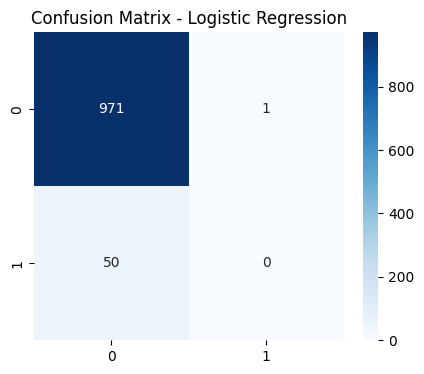

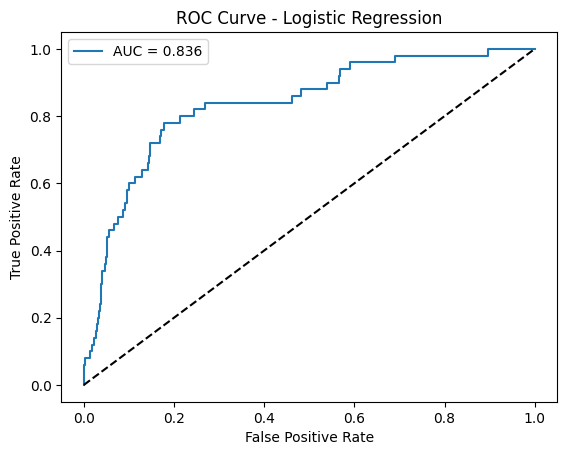

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:,1]

# --- Đánh giá
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# --- Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# --- ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()


Accuracy: 0.9481409001956947
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



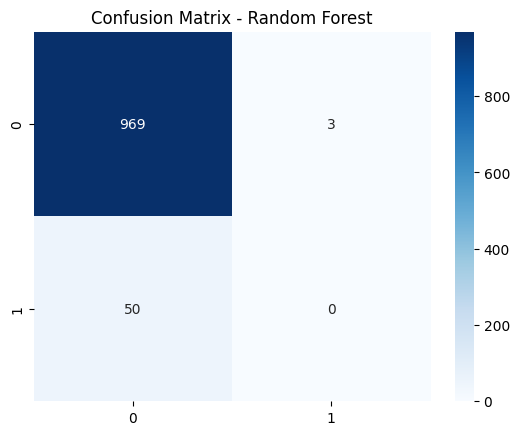

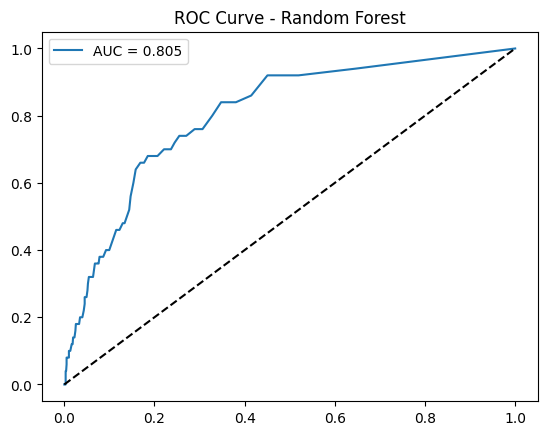

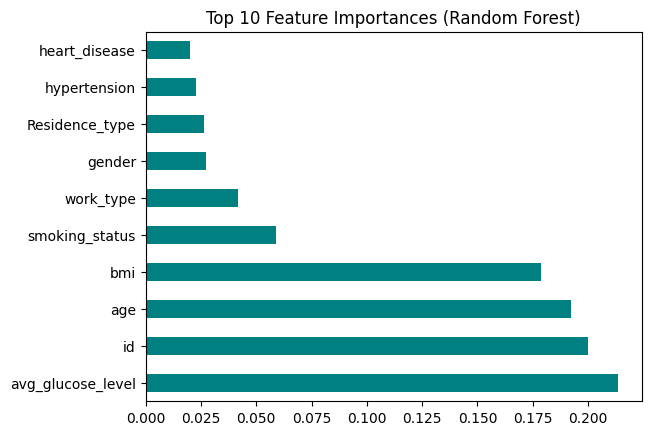

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

# --- Đánh giá
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# --- Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

# --- ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

# --- Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
feat_imp.head(10).plot(kind='barh', title="Top 10 Feature Importances (Random Forest)", color='teal')
plt.show()

